In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

#### STEP1: READ DAILY SENSOR DATA

In [3]:
df_la_daily= pd.read_csv("../data/la_daily_2017_2023.csv",parse_dates=["date"])
df_la_daily.set_index("date",inplace=True)
df_la_daily = df_la_daily.sort_index()
df_la_daily.head()


#df_la_daily = df.loc['2017':'2021']
#df_la_daily_2023 = df.loc['2023']
#df_la_daily_2023.shape


,pm25_cf_1,humidity,temperature,pressure
date,,,,
2017-01-01,25.714433,54.929449,59.433115,59.433218
2017-01-02,7.568054,53.618319,61.723596,61.726110
2017-01-03,18.169412,52.460524,62.956328,62.954285
2017-01-04,21.875172,51.506422,63.944057,63.943135
2017-01-05,16.650620,65.335559,65.901941,65.899936


#### STEP2: VISUALIZATION

### Plot for daily PM2.5 data (2017-2023)

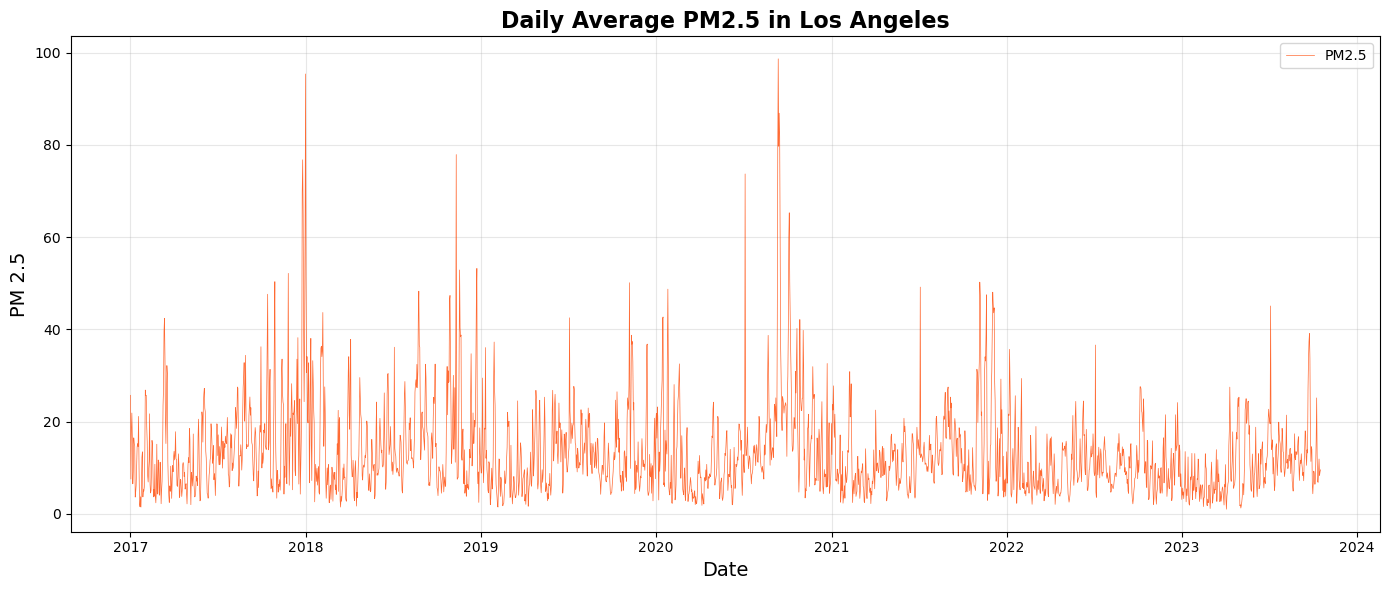

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_la_daily.index, df_la_daily['pm25_cf_1'],  color='orangered', linewidth=0.5, alpha=0.8, label='PM2.5')
ax.set_title('Daily Average PM2.5 in Los Angeles', fontsize=16, fontweight='bold')
ax.set_ylabel('PM 2.5',fontsize=14)
ax.set_xlabel('Date',fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/los_angeles_pm25_dailyaverage.png', dpi=300) 
plt.show()

### Histogram of PM2.5 distribution

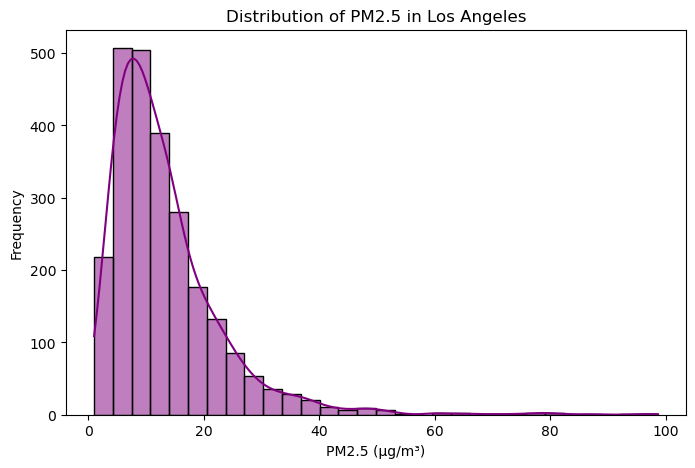

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df_la_daily['pm25_cf_1'], bins=30, kde=True, color='purple')

plt.title('Distribution of PM2.5 in Los Angeles')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.savefig('../figures/los_angeles_pm25_histogram.png', dpi=300) 
plt.show()

PM2.5 concentrations in Los Angeles shows non-normal right-skewed distribution. Most observations cluster around the 5–15 µg/m³ range. The long tail extends to 100, and this indicates rare but extreme pollution increases.

**We will plot monthly values for better visualization**

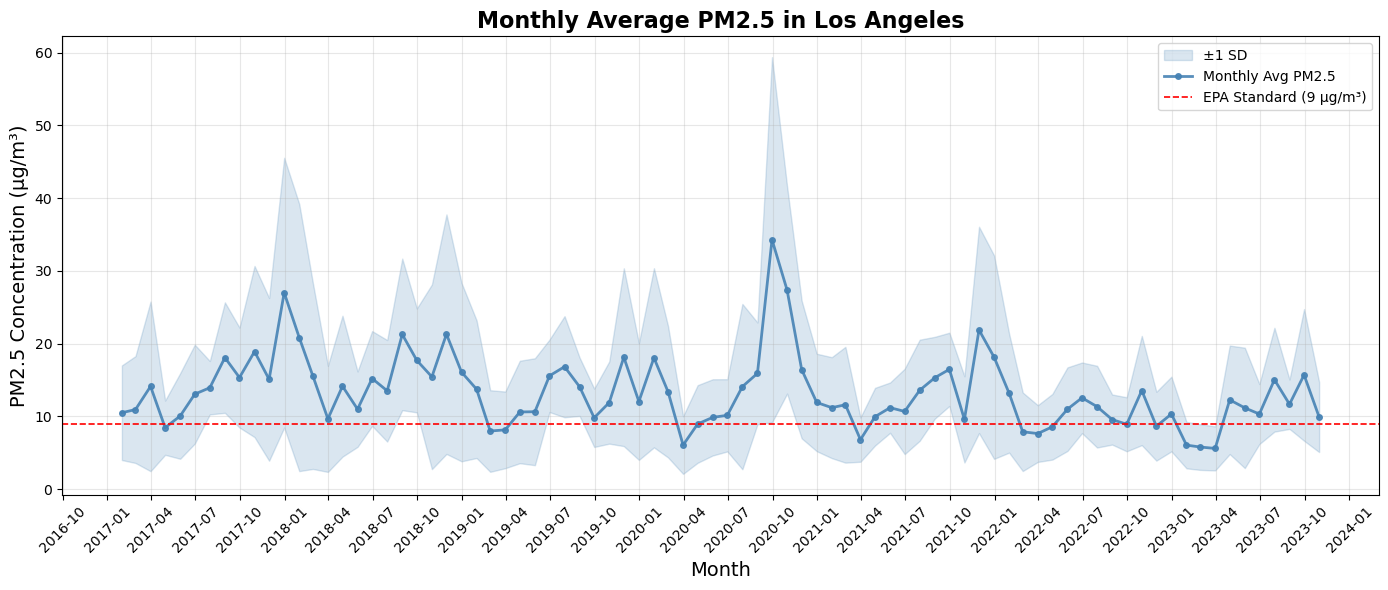

In [22]:
# Resample to monthly frequency
df_la_monthly = df_la_daily[['pm25_cf_1']].resample('ME').mean()
df_la_monthly['std'] = df_la_daily['pm25_cf_1'].resample('ME').std()

fig, ax = plt.subplots(figsize=(14, 6))

# Shaded band (±1 SD)
ax.fill_between(df_la_monthly.index,
                df_la_monthly['pm25_cf_1'] - df_la_monthly['std'],
                df_la_monthly['pm25_cf_1'] + df_la_monthly['std'],
                alpha=0.2, color='steelblue', label='±1 SD')

# Main line
ax.plot(df_la_monthly.index, df_la_monthly['pm25_cf_1'],
        color='steelblue', linewidth=2, marker='o', markersize=4,
        alpha=0.9, label='Monthly Avg PM2.5')

# EPA reference line
ax.axhline(y=9, color='red', linestyle='--', linewidth=1.2, label='EPA Standard (9 µg/m³)')

ax.set_title('Monthly Average PM2.5 in Los Angeles', fontsize=16, fontweight='bold')
ax.set_ylabel('PM2.5 Concentration (μg/m³)', fontsize=14)
ax.set_xlabel('Month', fontsize=14)

# Format x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/los_angeles_pm25_monthly_avg.png', dpi=300)
plt.show()

There are some sudden spikes.This might be due to wild fire happened in 2017, 2018 and 2020 in LA.

Long-term trend is downward which means PM2.5 started to decrease in 2022.

### Weekday vs weekend PM2.5 differences in the PM2.5 concentration

Air pollution is expected to exhibit weekly seasonality, with higher levels during weekdays and lower levels on weekends.
We will plot the weekday vs weekend PM2.5 differences in the PM2.5 concentration

day_type
Weekday    13.051428
Weekend    13.884366
Name: pm25_cf_1, dtype: float64


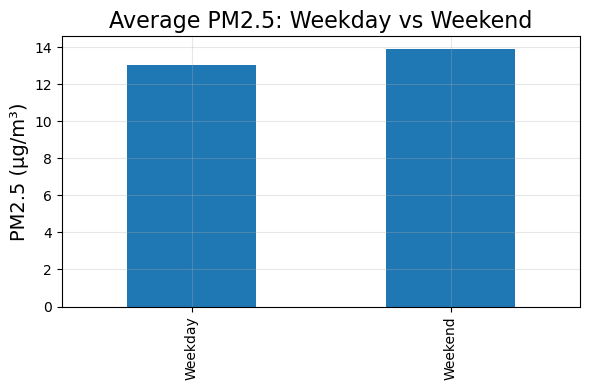

In [23]:
df_la_daily['is_weekend'] = df_la_daily.index.weekday >= 5
df_la_daily['day_type'] = df_la_daily['is_weekend'].map({False:'Weekday', True:'Weekend'})

print(df_la_daily.groupby('day_type')['pm25_cf_1'].mean())

weekday_weekend = df_la_daily.groupby('day_type')['pm25_cf_1'].mean()

fig, ax = plt.subplots(figsize=(6,4))

weekday_weekend.plot(kind='bar', ax=ax)

ax.set_title('Average PM2.5: Weekday vs Weekend', fontsize=16)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=14)
ax.set_xlabel('')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/los_angeles_pm25_weekday_weekend.png', dpi=300) 
plt.show()

This plot suggests weak weekly seasonality in PM2.5 concentrations, indicating that pollution levels are likely influenced more by external factors such as meteorological conditions than by weekday human activity patterns.

In [24]:
weekday_mean=df_la_daily[df_la_daily['day_type']=='Weekday']['pm25_cf_1'].mean()
weekend_mean=df_la_daily[df_la_daily['day_type']=='Weekend']['pm25_cf_1'].mean()

difference = weekend_mean - weekday_mean 
percent_diff = (difference / weekday_mean) * 100

print("Weekday PM2.5:", weekday_mean)
print("Weekend PM2.5:", weekend_mean)
print("Difference:", difference)
print("Percent difference:", percent_diff)

Weekday PM2.5: 13.051428067190887
Weekend PM2.5: 13.884365587009892
Difference: 0.832937519819005
Percent difference: 6.381964605948914


The average PM2.5 concentration on weekdays is 13.05 μg/m³, while the average concentration on weekends is 13.89 μg/m³. This indicates that weekend pollution levels were approximately 0.83 μg/m³ (6.38%) higher than weekday levels.

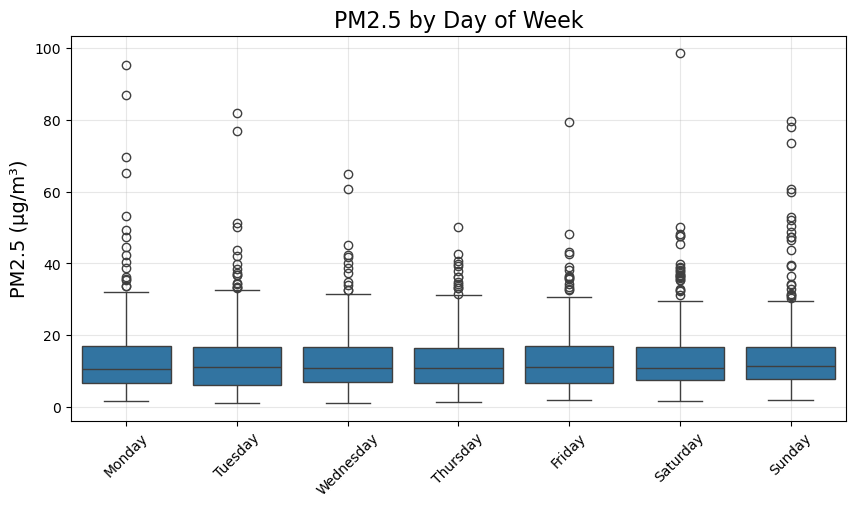

In [25]:
df_la_daily['day_of_week'] = df_la_daily.index.day_name()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))

sns.boxplot(data=df_la_daily, x='day_of_week', y='pm25_cf_1', order=order)

plt.title('PM2.5 by Day of Week',fontsize=16)
plt.ylabel('PM2.5 (μg/m³)',fontsize=14)
plt.xlabel('')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.savefig('../figures/los_angeles_pm25_dayofweek.png', dpi=300) 
plt.show()

The median PM2.5 values are very similar across all days. Most medians appear around 10 μg/m³. There is no large difference between weekdays and weekends. There are many outliers in the box plot. Those high-level PM2.5 concentrations may represent extreme air pollution events, such as wildfires and unusual atmospheric conditions.

### Correlation between PM2.5 and humidity/ temperature

In [26]:
corr_matrix = df_la_daily[['pm25_cf_1','humidity','temperature']].corr()
print(corr_matrix)

             pm25_cf_1  humidity  temperature
pm25_cf_1     1.000000  0.186807     0.155491
humidity      0.186807  1.000000     0.004378
temperature   0.155491  0.004378     1.000000


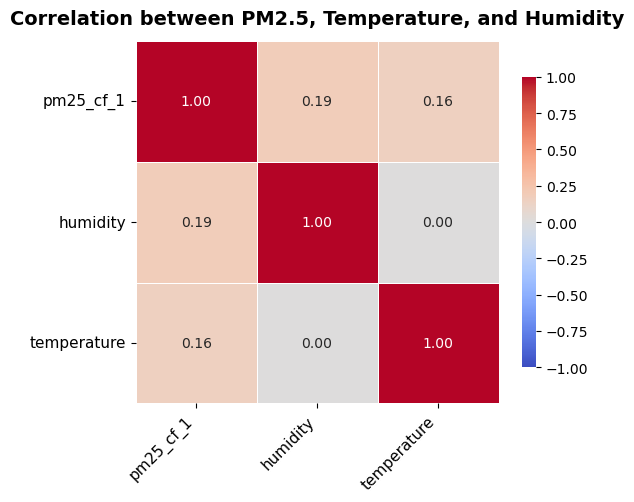

In [27]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1,      
    square=True,          
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation between PM2.5, Temperature, and Humidity',
          fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('../figures/los_angeles_correlation_heatmap.png', dpi=300)
plt.show()

This correlation analysis shows that there is no strong correlation between humidity, temperature, and PM2.5 for Log Angeles data we are using.

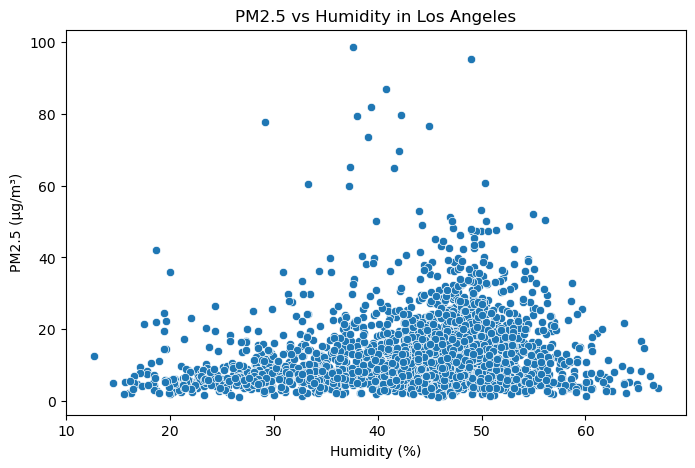

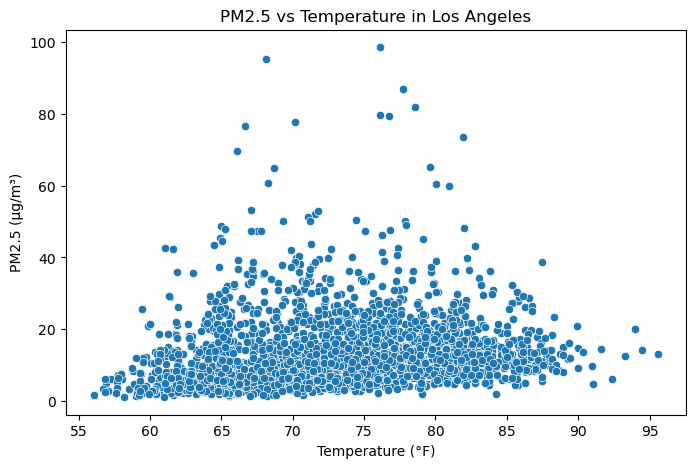

In [28]:
# Scatter plot: PM2.5 vs Humidity
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_la_daily, x='humidity', y='pm25_cf_1')
plt.title('PM2.5 vs Humidity in Los Angeles')
plt.xlabel('Humidity (%)')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

# Scatter plot: PM2.5 vs Temperature
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_la_daily, x='temperature', y='pm25_cf_1')
plt.title('PM2.5 vs Temperature in Los Angeles')
plt.xlabel('Temperature (°F)')
plt.ylabel('PM2.5 (µg/m³)')
plt.savefig('../figures/los_angeles_pm25_scatterplot.png', dpi=300) 
plt.show()

The scatter plots also suggest that there is no linear relationship between humidity/temperature and PM2.5. Both temperature and humidity show a similar relationship with PM2.5

#### STEP3: SEASONAL DECOMPOSITION

##### ADDITIVE DECOMPOSITION

##### First Weekly Decompostion

pm25_cf_1      0
humidity       0
temperature    0
is_weekend     0
day_type       0
day_of_week    0
dtype: int64
date
0    0.101029
1   -0.247856
2   -0.408235
3   -0.326593
4   -0.291045
5    0.427319
6    0.745383
Name: seasonal, dtype: float64

Component Statistics:
----------------------------------------------------------------------
Trend (Long-term movement):
  Mean: 13.29 µg/m³
  Min: 2.82 µg/m³, Max: 75.41 µg/m³

Seasonal (Weekly Pattern):
  Amplitude: 1.15 µg/m³
  Peak effect: 0.75 µg/m³
  Trough effect: -0.41 µg/m³

Residual (Noise/Unexplained Variation):
  Std Dev: 5.64 µg/m³


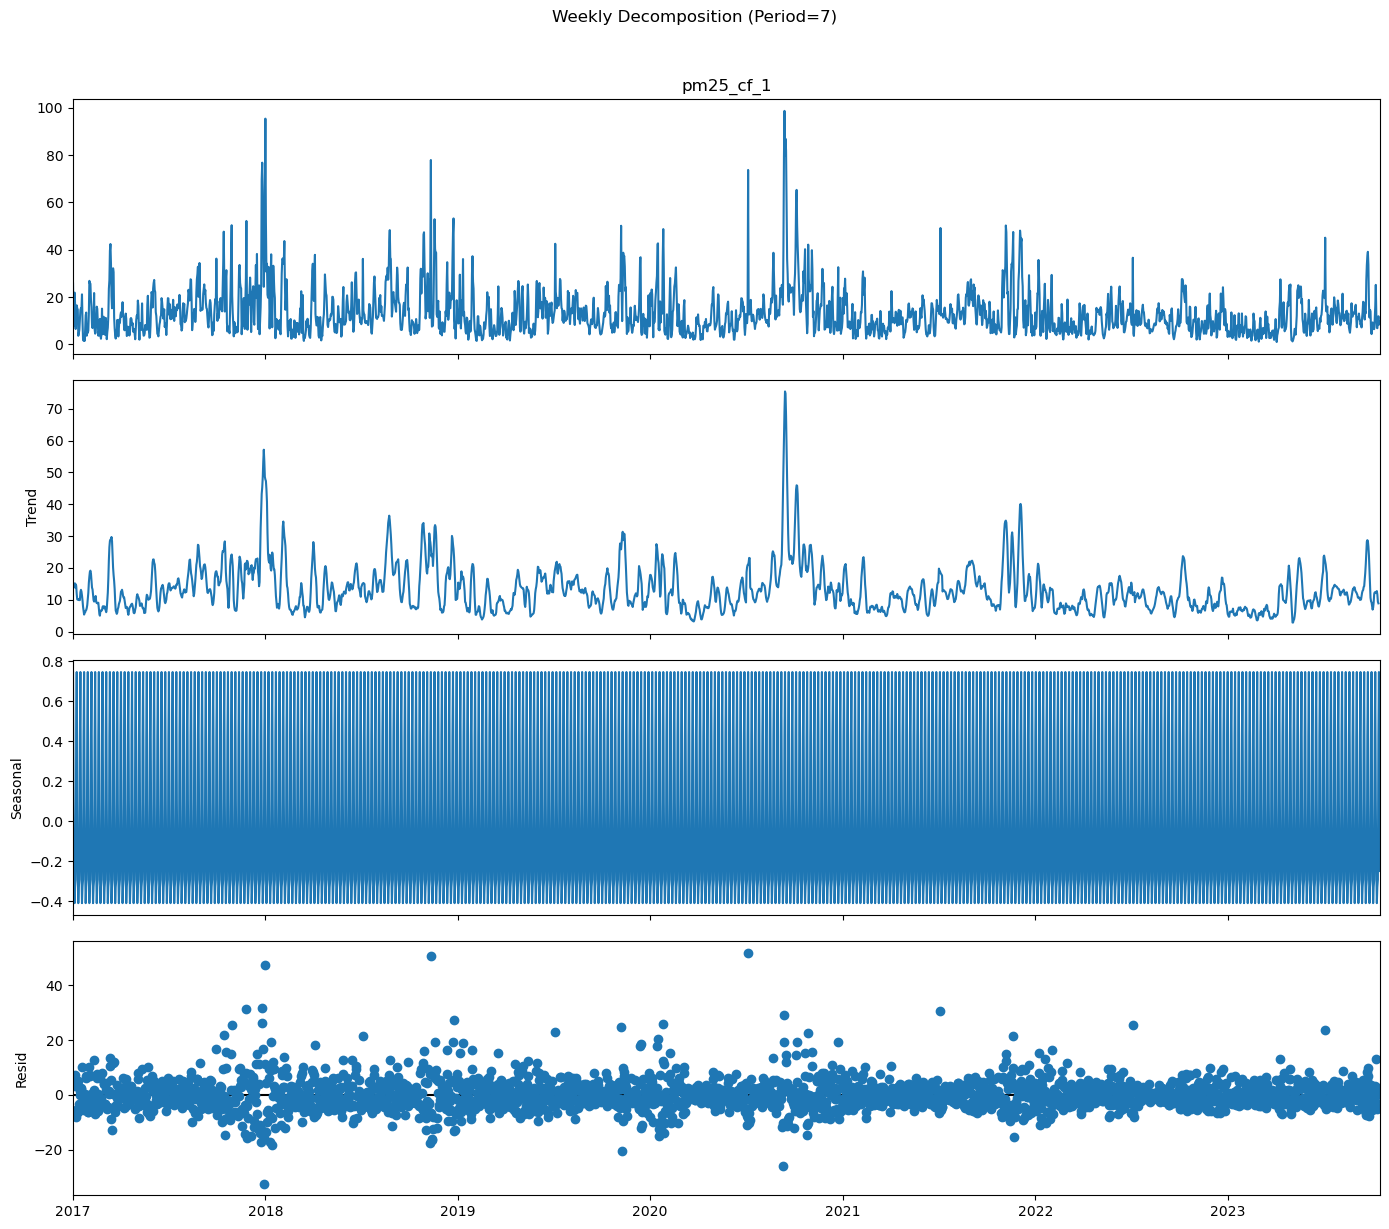

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

print(df_la_daily.isnull().sum())

# Weekly decompositon
decomp_weekly = seasonal_decompose(df_la_daily['pm25_cf_1'], model='additive', period=7)


# Extract components
trend = decomp_weekly.trend
seasonal = decomp_weekly.seasonal
residual = decomp_weekly.resid

seasonal_by_day = seasonal.groupby(seasonal.index.dayofweek).mean()
print(seasonal_by_day)

print("\nComponent Statistics:")
print("-" * 70)

print("Trend (Long-term movement):")
print(f"  Mean: {trend.mean():.2f} µg/m³")
print(f"  Min: {trend.min():.2f} µg/m³, Max: {trend.max():.2f} µg/m³")

print("\nSeasonal (Weekly Pattern):")
print(f"  Amplitude: {seasonal.max() - seasonal.min():.2f} µg/m³")
print(f"  Peak effect: {seasonal.max():.2f} µg/m³")
print(f"  Trough effect: {seasonal.min():.2f} µg/m³")

print("\nResidual (Noise/Unexplained Variation):")
print(f"  Std Dev: {residual.std():.2f} µg/m³")
# Visualize components
fig = decomp_weekly.plot()
fig.set_size_inches(14, 12)
plt.suptitle("Weekly Decomposition (Period=7)", y=1.02)
plt.tight_layout()
plt.show()

##### Yearly Decompostion


Component Statistics:
----------------------------------------------------------------------
Trend (Long-term movement):
  Mean: 13.52 µg/m³
  Min: 9.22 µg/m³, Max: 17.13 µg/m³

Seasonal (Weekly Pattern):
  Amplitude: 29.82 µg/m³
  Peak effect: 21.52 µg/m³
  Trough effect: -8.30 µg/m³

Residual (Noise/Unexplained Variation):
  Std Dev: 8.81 µg/m³


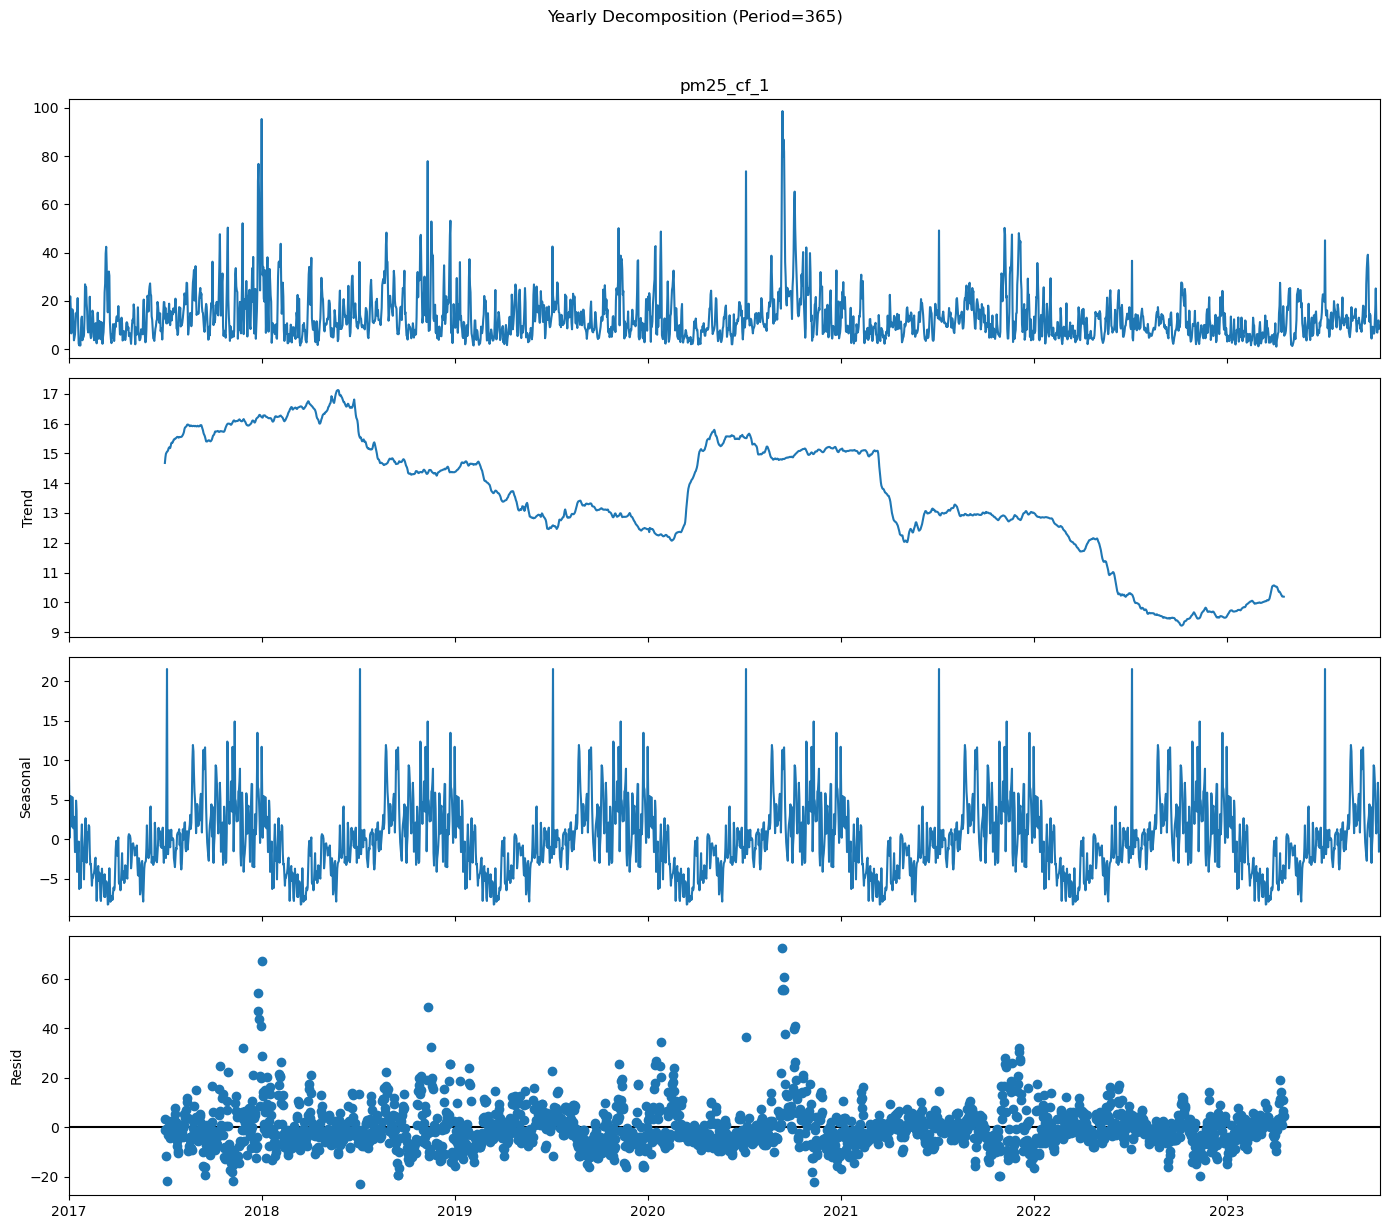

In [30]:
# Yearly decompositon
decomp_yearly = seasonal_decompose(df_la_daily['pm25_cf_1'], model='additive', period=365)


# Extract components
trend = decomp_yearly.trend
seasonal = decomp_yearly.seasonal
residual = decomp_yearly.resid


print("\nComponent Statistics:")
print("-" * 70)

print("Trend (Long-term movement):")
print(f"  Mean: {trend.mean():.2f} µg/m³")
print(f"  Min: {trend.min():.2f} µg/m³, Max: {trend.max():.2f} µg/m³")

print("\nSeasonal (Weekly Pattern):")
print(f"  Amplitude: {seasonal.max() - seasonal.min():.2f} µg/m³")
print(f"  Peak effect: {seasonal.max():.2f} µg/m³")
print(f"  Trough effect: {seasonal.min():.2f} µg/m³")

print("\nResidual (Noise/Unexplained Variation):")
print(f"  Std Dev: {residual.std():.2f} µg/m³")
# Visualize components
fig = decomp_yearly.plot()
fig.set_size_inches(14, 12)
plt.suptitle("Yearly Decomposition (Period=365)", y=1.02)
plt.tight_layout()
plt.show()